# HW 2 Coding Questions - Sophia Chung

## Question 6

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import statsmodels.formula.api as smf
from plotnine import *
import scipy.stats as stats

In [2]:
infection_rate = pd.read_csv("./data/hospital_infection.csv")
n = len(infection_rate)
infection_rate.head()

,ID,Stay,Age,InfctRsk,Culture,Xray,Beds,MedSchool,Region,Census,Nurses,Facilities
0,5,11.20,56.5,5.7,34.5,88.9,180,2,1,134,151,40.0
1,10,8.84,56.3,6.3,29.6,82.6,85,2,1,59,66,40.0
2,11,11.07,53.2,4.9,28.5,122.0,768,1,1,591,656,80.0
3,13,12.78,56.8,7.7,46.0,116.9,322,1,1,252,349,57.1
4,18,11.62,53.9,6.4,25.5,99.2,133,2,1,113,101,37.1


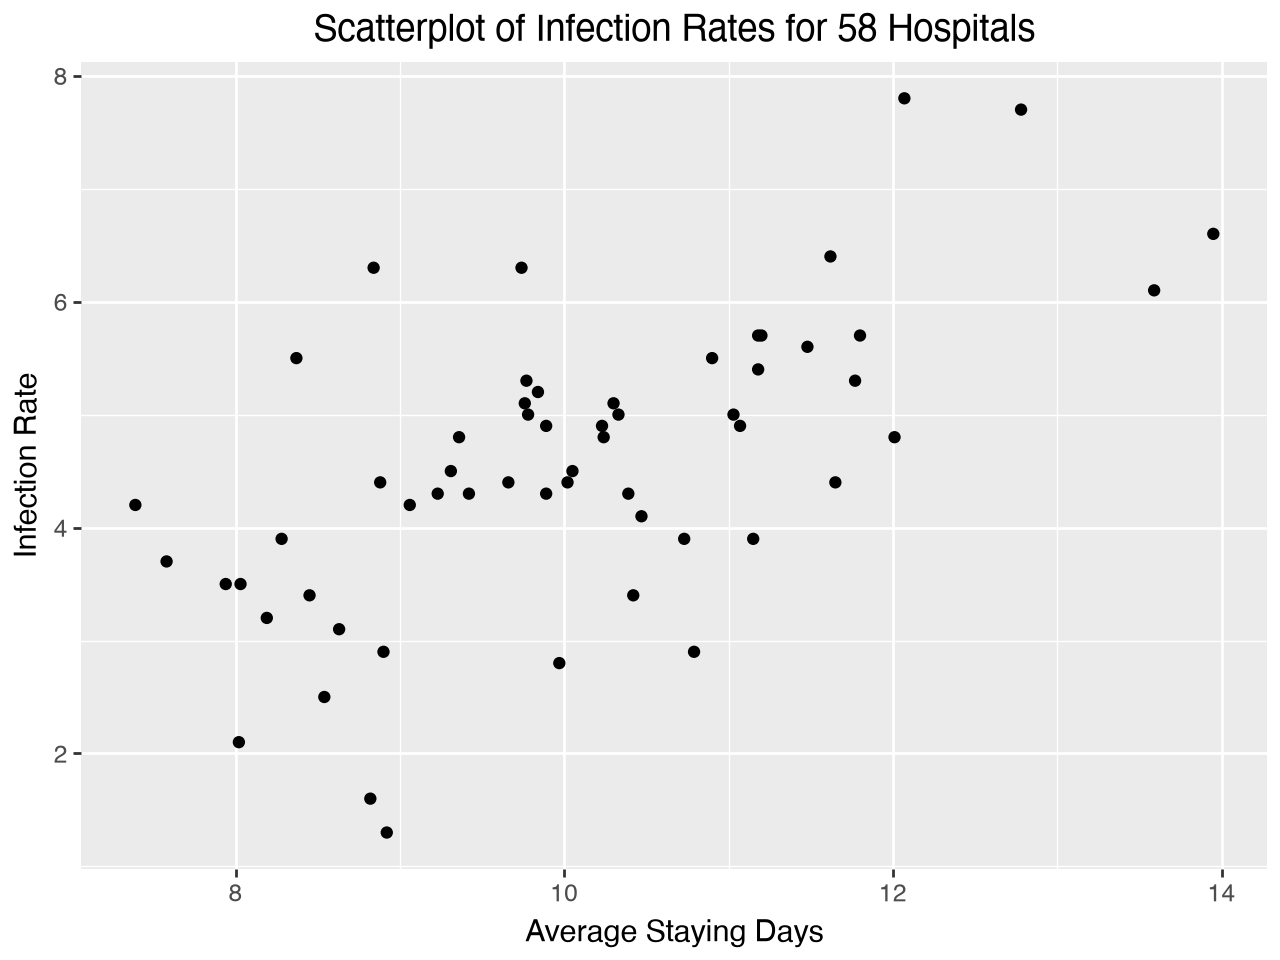

In [3]:
ggplot(infection_rate, aes(x='Stay', y='InfctRsk')) + \
    geom_point() + \
    labs(title='Scatterplot of Infection Rates for 58 Hospitals',
          x='Average Staying Days', y='Infection Rate')

**(a)** There seems to be a positive linear relationship, although not a very strong one.

In [4]:
X = infection_rate[['Stay']]
y = infection_rate[['InfctRsk']]
model = LinearRegression().fit(X, y)

slope = round(model.coef_[0][0], 4)
intercept = round(model.intercept_[0], 4)
print(f"Slope: {slope}, Intercept: {intercept}")

Slope: 0.5689, Intercept: -1.1598


**(b)** $\hat{y}_i = -1.1598 + 0.5689x_i$ where $\hat{y}_i$ is the fitted infection rate and $x_i$ is average staying days for hospital $i$.

In [5]:
mod_infection = smf.ols('InfctRsk ~ Stay', data=infection_rate).fit()
mod_infection.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               InfctRsk   R-squared:                       0.395
Model:                            OLS   Adj. R-squared:                  0.384
Method:                 Least Squares   F-statistic:                     36.50
Date:                Sun, 13 Sep 2026   Prob (F-statistic):           1.30e-07
Time:                        18:01:36   Log-Likelihood:                -82.684
No. Observations:                  58   AIC:                             169.4
Df Residuals:                      56   BIC:                             173.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.1598      0.956     -1.213      0.230      -3.075       0.755
Stay           0.5689      0.094      6.041      0.000       0.380       0.757
==============================================================================
Omnibus:                        1.579   Durbin-Watson:                   2.075
Prob(Omnibus):                  0.454   Jarque-Bera (JB):                0.839
Skew:                          -0.170   Prob(JB):                        0.657
Kurtosis:                       3.481   Cond. No.                         72.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**(c)** The test (t) statistic of the coefficient of Stay ($\beta_1$) is 6.041, and the p-value is 0. This very low p-value (it can't actually get any lower) suggests that average staying days has a statistically significant linear relationship with infection rate at a hospital (at the 5% significance level).

In [ ]:
beta_hat = list(mod_infection.params)

def yhat(x, beta_hat=beta_hat):
    return beta_hat[0] + beta_hat[1] * x

alpha = 0.05
crit = stats.t.ppf(1 - alpha/2, df=n-2)

sigma2hat = sum(mod_infection.resid**2) / (n - 2)
sigmahat = np.sqrt(sigma2hat)

x_values = infection_rate['Stay']
xbar = np.mean(x_values)
SSX = sum((x_values - xbar)**2)

se_beta1 = sigmahat / np.sqrt(SSX)
ci_beta1 = beta_hat[1] + np.array([-1, 1]) * crit * se_beta1
print(f"95% CI for beta_1: ", ci_beta1)

95% CI for beta_1:  [0.38023343 0.75749948]


**(d)** The 95% confidence interval for $\beta_1$ that I calculated matches the result from the summary output from (c). The interval does not contain 0 and thus remains consistent with our conclusion from (c).

In [7]:
aov_table = sm.stats.anova_lm(mod_infection, typ=1)
aov_table

,df,sum_sq,mean_sq,F,PR(>F)
Stay,1.0,38.305918,38.305918,36.496522,1.302453e-07
Residual,56.0,58.776324,1.049577,NaN,NaN


**(e)** The test (F) statistic is 36.4965 and the p-value of the F-test is approximately zero. This again suggests that average staying days is a statistically significant predictor of infection rate at a hospital.

In [8]:
print(6.041**2)

36.493681


**(f)** The square of the t-statistic from earlier is approximately equal to the F-statistic from ANOVA (I used the rounded t-statistic). The p-values are also both approximately zero.

**(g)** $R^2$ is 0.395, suggesting that the model is a decent fit, though it could be a stronger fit. 39.5% of the variability in infection rate is explained by the model.

In [9]:
x = 32
new = pd.DataFrame({'Stay': [x]})
pred = round(model.predict(new)[0][0], 4)
print(pred)

17.0439


**(h)** My predicted infection rate for a hospital with an average stay length of 32 days is 17.0439%. It is important to note that $x=32$ is an extrapolation since it lies way outside of our observed range of 7-14 days, so this prediction should be taken with a grain of salt.

## Question 7

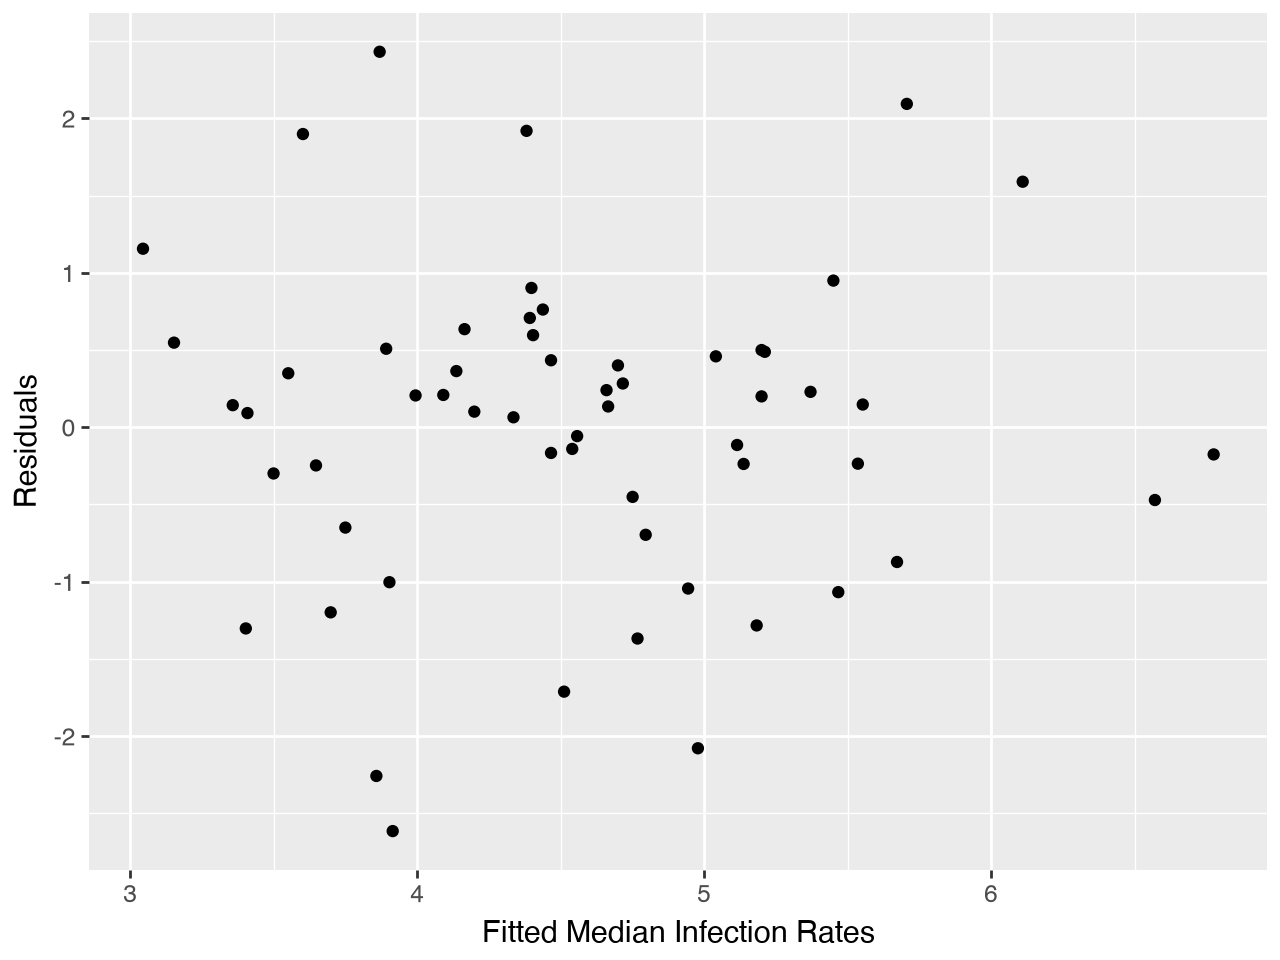

In [10]:
infection_rate.loc[:, 'predicted'] = mod_infection.fittedvalues
infection_rate.loc[:, 'residuals'] = mod_infection.resid

plot_infct_resid = (
    ggplot(infection_rate, aes(x='predicted', y='residuals')) +
    geom_point() +
    labs(x='Fitted Median Infection Rates', y='Residuals')
)
plot_infct_resid

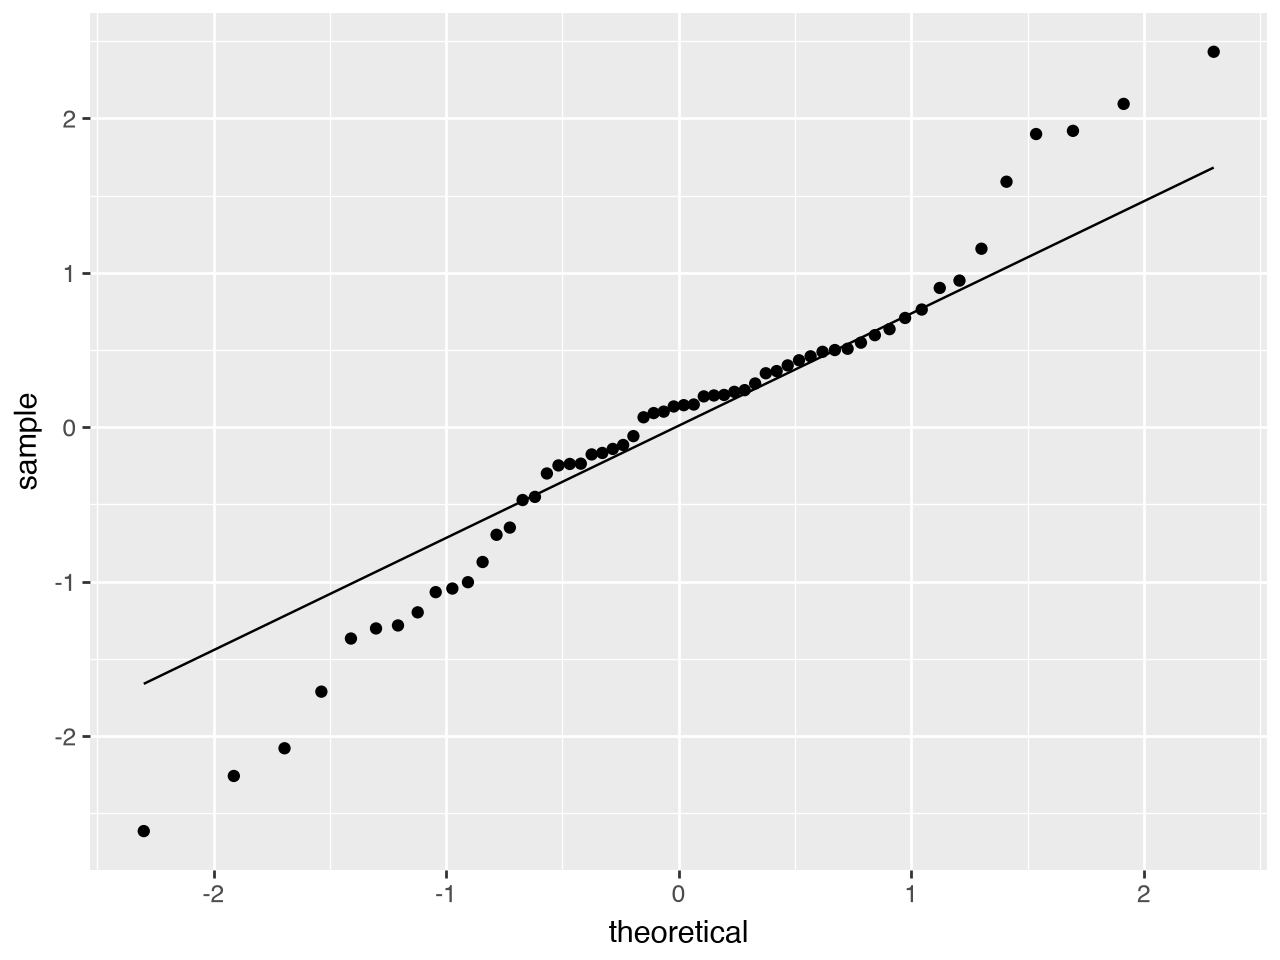

In [11]:
(ggplot(infection_rate, aes(sample='residuals')) +
    stat_qq() + stat_qq_line())

**(a)** From the residual plot, it appears that infection risk and stay length have a linear relationship because the points appear randomly scattered.

**(b)** From the residual plot, it appears that the error terms do not have constant variance, especially for the extreme values of $y$ that seem to be more varied.

**(c)** The points in the residual plot are randomly scattered and there is no obvious wave-like pattern or clustering, so the error terms appear independent.

**(d)** In the QQ plot, the points create a somewhat symmetric "S" shape, meaning that the residuals have a symmetric distribution with heavier tails than a Normal distribution.

Overall, I would proceed with caution since the assumptions are not fully met.

## Question 8

In [ ]:
def seyhat(x, sigmahat=sigmahat, n=n, xbar=xbar, SSX=SSX):
    return sigmahat * np.sqrt(1/n + (x - xbar)**2 / SSX)

ci = yhat(x=x) + np.array([-1, 1]) * crit * seyhat(x=x)

def sepred(x, sigmahat=sigmahat, n=n, xbar=xbar, SSX=SSX):
    return sigmahat * np.sqrt(1 + 1/n + (x - xbar)**2 / SSX)

pi = yhat(x=x) + np.array([-1, 1]) * crit * sepred(x=x)

print(f"95% CI: ", ci)
print(f"95% PI: ", pi)

# double check PI
mod_infection.get_prediction(new).summary_frame(alpha=alpha)

95% CI:  [12.89452279 21.19329248]
95% PI:  [12.41472629 21.67308899]


,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,17.043908,2.071336,12.894523,21.193292,12.414726,21.673089
